# 📨 Message Intelligence System
### Spam vs Legitimate Message Classification using Probability Theory & Machine Learning

**Role:** Data Scientist, Communication Security Company
**Objective:** Build and compare distance-based (KNN), margin-based (SVM), and probabilistic (Naive Bayes) classifiers to detect spam messages, and explain performance using probability concepts.

- `0` → Legitimate Message
- `1` → Spam Message

---


## 🧠 Part A: Probability & Conceptual Foundation (Theory)

### 1. What is Conditional Probability?

Conditional probability is the probability of an event **A** occurring given that another event **B** has already occurred. It is defined as:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0$$

In a spam classification context, this answers questions like: *"What is the probability a message is spam, given that it contains the word 'free'?"* It lets us update our belief about the class label after observing evidence (features) rather than relying on the unconditional (prior) probability alone.

### 2. Bayes' Theorem and its importance in classification

Bayes' Theorem relates conditional probabilities in reverse order:

$$P(Y \mid X) = \frac{P(X \mid Y)\, P(Y)}{P(X)}$$

Where:
- $P(Y)$ = **prior** probability of class Y (e.g., spam)
- $P(X \mid Y)$ = **likelihood** of observing features X given class Y
- $P(X)$ = **evidence** (marginal probability of X)
- $P(Y \mid X)$ = **posterior** probability of class Y given features X

**Importance in classification:** It is often easy to estimate $P(X \mid Y)$ from training data (how spam messages typically look) but hard to directly estimate $P(Y \mid X)$ (whether THIS message is spam). Bayes' Theorem lets us flip the easy-to-estimate likelihood into the posterior probability we actually need for decision-making — this is the foundation of the **Naive Bayes Classifier**.

### 3. Assumptions of the Naive Bayes Classifier

- **Conditional independence**: Given the class label, all features are assumed to be independent of one another. i.e. $P(X_1, X_2, ..., X_n \mid Y) = \prod_i P(X_i \mid Y)$.
- **Feature distribution assumption**: For continuous features (as in this dataset), Gaussian Naive Bayes assumes each feature is normally distributed within each class.
- **Equal importance is not assumed** — each feature can have a different distribution per class, but they are assumed to contribute independently to the posterior.
- In reality, features like `message_length` and `word_count` are correlated, which **violates** the independence assumption — yet Naive Bayes often still performs reasonably well in practice.

### 4. Working Principle

**K-Nearest Neighbors (KNN):**
KNN is a **distance-based, non-parametric, lazy-learning** algorithm. To classify a new message, it computes the distance (e.g., Euclidean) between the new point and all training points, selects the **K** closest neighbors, and assigns the **majority class label** among those neighbors. There is no explicit training phase — all computation happens at prediction time.

**Support Vector Machine (SVM):**
SVM is a **margin-based** classifier that finds the optimal **hyperplane** that separates the two classes with the **maximum margin** (the distance between the hyperplane and the nearest points of each class, called **support vectors**). For non-linearly separable data, SVM uses the **kernel trick** (e.g., RBF, polynomial) to implicitly map data into a higher-dimensional space where a linear separator can be found.

### 5. Comparison: Distance-based vs Probabilistic vs Margin-based Classifiers

| Aspect | KNN (Distance-based) | Naive Bayes (Probabilistic) | SVM (Margin-based) |
|---|---|---|---|
| Core idea | Majority vote of nearest neighbors | Posterior probability via Bayes' theorem | Maximum-margin separating hyperplane |
| Training time | None (lazy learner) | Fast (estimates means/variances) | Can be slow on large data (quadratic optimization) |
| Prediction time | Slow (compares to all points) | Very fast | Fast |
| Assumptions | None on distribution, but sensitive to scale | Feature independence + distribution assumption | Assumes a separating margin exists (or uses kernel) |
| Sensitive to outliers | Yes (distance-based) | Less sensitive | Only support vectors matter |
| Interpretability | Medium | High (probabilities are interpretable) | Low (especially with non-linear kernels) |
| Handles high dimensions | Poorly (curse of dimensionality) | Well | Well |

---


## 🧪 Part B: Dataset Understanding & Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("Message_Intelligence_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   str    
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   str    
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week              5200 non-n

In [ ]:
df.describe()

,count,mean,std,min,25%,50%,75%,max
message_id,5200.0,902600.500000,1501.255031,900001.0,901300.75,902600.5,903900.25,905200.0
message_length,5200.0,75.035962,12.455377,32.0,67.00,74.0,81.00,122.0
word_count,5200.0,11.457308,1.609056,5.0,10.00,11.0,13.00,16.0
num_urls,5200.0,0.206538,0.404860,0.0,0.00,0.0,0.00,1.0
num_digits,5200.0,1.681346,2.415846,0.0,0.00,0.0,4.00,9.0
num_special_chars,5200.0,0.243654,0.545363,0.0,0.00,0.0,0.00,2.0
spam_keyword_score,5200.0,0.246346,0.676798,0.0,0.00,0.0,0.00,3.0
legit_keyword_score,5200.0,0.817692,0.556687,0.0,0.00,1.0,1.00,2.0
sender_activity_score,5094.0,54.836317,17.697943,5.0,43.10,54.8,66.60,100.0
sender_account_age_days,5087.0,296.671909,191.748754,2.0,148.00,275.0,410.50,1500.0


### Task 6 — Identify input features and target variable

In [4]:
target_col = "spam_label"

feature_cols = [
    "message_length", "word_count", "num_urls", "num_digits",
    "num_special_chars", "spam_keyword_score", "legit_keyword_score",
    "sender_activity_score", "sender_account_age_days",
    "messages_sent_last_24h", "hour_of_day", "day_of_week"
]

print("Target:", target_col)
print("Features:", feature_cols)
print("\nClass distribution:")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True).round(3))

Target: spam_label
Features: ['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']

Class distribution:
spam_label
0    4227
1     973
Name: count, dtype: int64
spam_label
0    0.813
1    0.187
Name: proportion, dtype: float64


/tmp/ipykernel_579/1832873301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette=["#4C72B0", "#DD8452"])


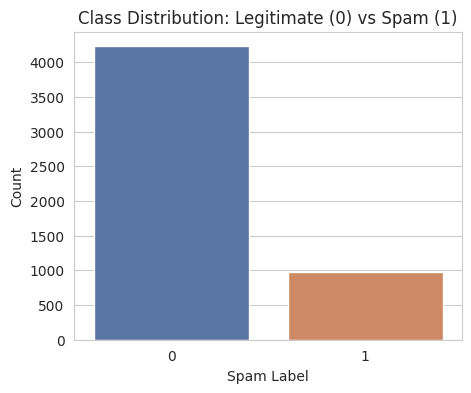

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Class Distribution: Legitimate (0) vs Spam (1)")
plt.xlabel("Spam Label")
plt.ylabel("Count")
plt.show()

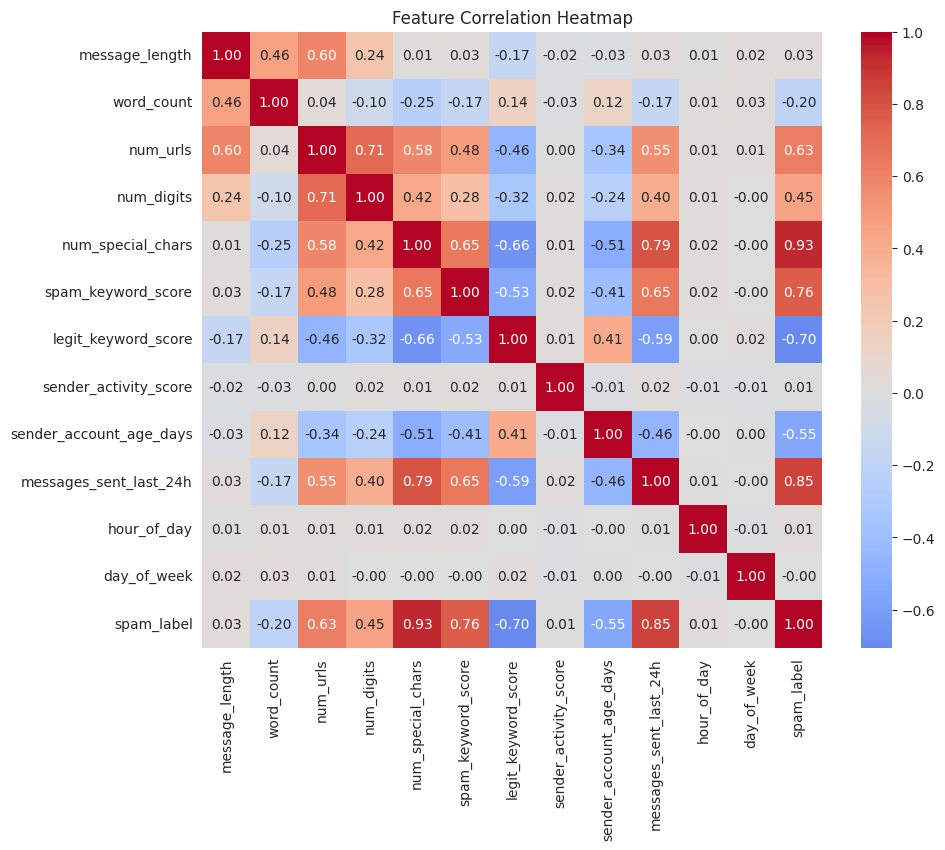

In [6]:
plt.figure(figsize=(10,8))
corr = df[feature_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

### Task 7 — Data preprocessing

In [ ]:
print("Missing values per column:")
print(df[feature_cols + [target_col]].isnull().sum())

Missing values per column:
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64


In [ ]:
for col in feature_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled {col} missing values with median = {median_val:.2f}")

print("\nRemaining missing values:", df[feature_cols].isnull().sum().sum())

Filled sender_activity_score missing values with median = 54.80
Filled sender_account_age_days missing values with median = 275.00
Filled messages_sent_last_24h missing values with median = 7.00

Remaining missing values: 0


In [9]:
X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape, " y shape:", y.shape)

X shape: (5200, 12)  y shape: (5200,)


### Task 8 — Train / Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (3900, 12)  Test shape: (1300, 12)

Train class balance:
 spam_label
0    0.813
1    0.187
Name: proportion, dtype: float64

Test class balance:
 spam_label
0    0.813
1    0.187
Name: proportion, dtype: float64


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

X_train_scaled.describe().T[["mean", "std"]]

,mean,std
message_length,-3.771342e-16,1.000128
word_count,1.293552e-16,1.000128
num_urls,-3.370523e-17,1.000128
num_digits,-9.109522e-18,1.000128
num_special_chars,3.324976e-17,1.000128
spam_keyword_score,7.378713e-17,1.000128
legit_keyword_score,-1.275333e-17,1.000128
sender_activity_score,-1.730809e-17,1.000128
sender_account_age_days,-9.747189e-17,1.000128
messages_sent_last_24h,-1.566838e-16,1.000128


---

## 📊 Part C: Baseline Model – K-Nearest Neighbors

### Task 9 & 10 — Implement KNN and experiment with different K values

In [12]:
k_values = range(1, 31, 2)
k_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    k_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    })

k_results_df = pd.DataFrame(k_results)
k_results_df

,K,Accuracy,Precision,Recall,F1
0,1,1.000000,1.0,1.000000,1.000000
1,3,1.000000,1.0,1.000000,1.000000
2,5,1.000000,1.0,1.000000,1.000000
3,7,0.999231,1.0,0.995885,0.997938
4,9,0.999231,1.0,0.995885,0.997938
5,11,0.999231,1.0,0.995885,0.997938
6,13,0.999231,1.0,0.995885,0.997938
7,15,0.999231,1.0,0.995885,0.997938
8,17,0.999231,1.0,0.995885,0.997938
9,19,0.999231,1.0,0.995885,0.997938


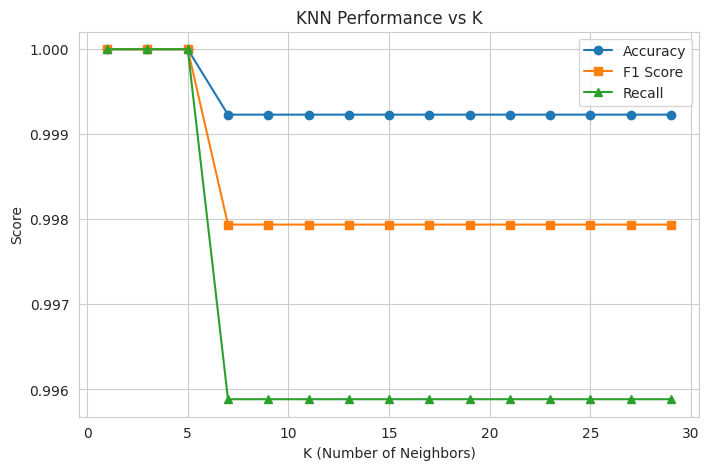

In [13]:
plt.figure(figsize=(8,5))
plt.plot(k_results_df["K"], k_results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(k_results_df["K"], k_results_df["F1"], marker="s", label="F1 Score")
plt.plot(k_results_df["K"], k_results_df["Recall"], marker="^", label="Recall")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Score")
plt.title("KNN Performance vs K")
plt.legend()
plt.show()

In [14]:
best_k = int(k_results_df.loc[k_results_df["F1"].idxmax(), "K"])
print("Best K (by F1 score):", best_k)

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_best.fit(X_train_scaled, y_train)
knn_preds = knn_best.predict(X_test_scaled)

print(classification_report(y_test, knn_preds, target_names=["Legitimate","Spam"]))

Best K (by F1 score): 1
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1057
        Spam       1.00      1.00      1.00       243

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



### Task 11 — Effect of distance metric

In [15]:
metrics_to_test = ["euclidean", "manhattan", "chebyshev"]
metric_results = []

for m in metrics_to_test:
    knn_m = KNeighborsClassifier(n_neighbors=best_k, metric=m)
    knn_m.fit(X_train_scaled, y_train)
    preds_m = knn_m.predict(X_test_scaled)
    metric_results.append({
        "Distance Metric": m,
        "Accuracy": accuracy_score(y_test, preds_m),
        "Precision": precision_score(y_test, preds_m, zero_division=0),
        "Recall": recall_score(y_test, preds_m, zero_division=0),
        "F1": f1_score(y_test, preds_m, zero_division=0)
    })

pd.DataFrame(metric_results)

,Distance Metric,Accuracy,Precision,Recall,F1
0,euclidean,1.000000,1.0,1.000000,1.000000
1,manhattan,1.000000,1.0,1.000000,1.000000
2,chebyshev,0.999231,1.0,0.995885,0.997938


### Task 12 — Misclassified cases by KNN

In [16]:
misclassified_idx = X_test_scaled.index[knn_preds != y_test.values]
misclassified_df = df.loc[misclassified_idx, ["message_text", "spam_label"]].copy()
misclassified_df["predicted_label"] = knn_preds[y_test.index.get_indexer(misclassified_idx)]
print(f"Total misclassified by KNN: {len(misclassified_df)} out of {len(y_test)}")
misclassified_df.head(10)

Total misclassified by KNN: 0 out of 1300


,message_text,spam_label,predicted_label


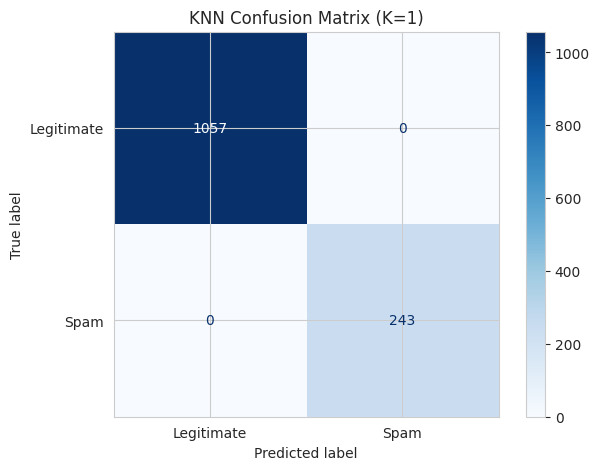

In [17]:
cm_knn = confusion_matrix(y_test, knn_preds)
disp = ConfusionMatrixDisplay(cm_knn, display_labels=["Legitimate","Spam"])
disp.plot(cmap="Blues")
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()

---

## ⚙️ Part D: Support Vector Machine Classifier

### Task 13 — SVM with Linear and RBF kernels

In [18]:
svm_linear = SVC(kernel="linear", probability=True, random_state=RANDOM_STATE, class_weight="balanced")
svm_linear.fit(X_train_scaled, y_train)
svm_linear_preds = svm_linear.predict(X_test_scaled)

svm_rbf = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, class_weight="balanced")
svm_rbf.fit(X_train_scaled, y_train)
svm_rbf_preds = svm_rbf.predict(X_test_scaled)

print("--- SVM (Linear Kernel) ---")
print(classification_report(y_test, svm_linear_preds, target_names=["Legitimate","Spam"]))

print("--- SVM (RBF Kernel) ---")
print(classification_report(y_test, svm_rbf_preds, target_names=["Legitimate","Spam"]))

--- SVM (Linear Kernel) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1057
        Spam       1.00      1.00      1.00       243

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300

--- SVM (RBF Kernel) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1057
        Spam       1.00      1.00      1.00       243

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



*Note: `class_weight="balanced"` is used to compensate for the ~81/19 class imbalance, so the model doesn't simply predict "legitimate" for everything.*

### Task 14 — Margin separation and support vectors

In [19]:
print("Linear Kernel:")
print(" Number of support vectors per class:", svm_linear.n_support_)
print(" Total support vectors:", svm_linear.n_support_.sum(), "out of", len(X_train_scaled), "training points")

print("\nRBF Kernel:")
print(" Number of support vectors per class:", svm_rbf.n_support_)
print(" Total support vectors:", svm_rbf.n_support_.sum(), "out of", len(X_train_scaled), "training points")

Linear Kernel:
 Number of support vectors per class: [6 6]
 Total support vectors: 12 out of 3900 training points

RBF Kernel:
 Number of support vectors per class: [73 62]
 Total support vectors: 135 out of 3900 training points


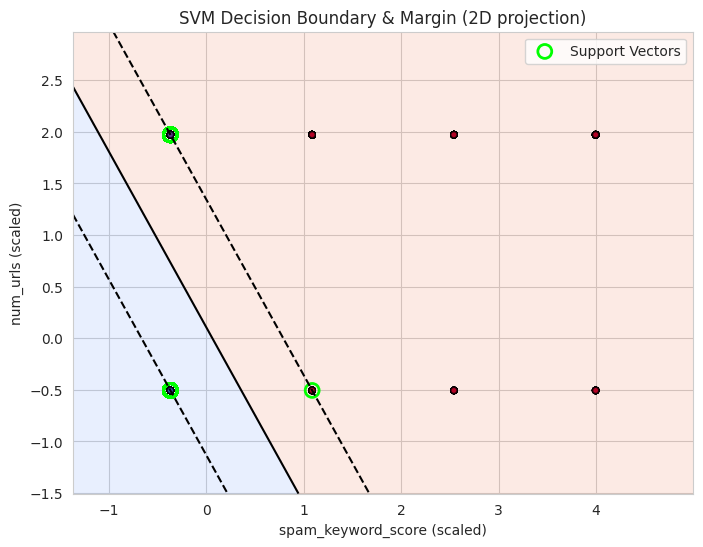

In [20]:
# Visualize margin separation using the 2 most informative features (PCA-free, domain-chosen)
from sklearn.svm import SVC as SVC2

feat_x, feat_y = "spam_keyword_score", "num_urls"
X_vis = X_train_scaled[[feat_x, feat_y]].values
y_vis = y_train.values

svm_vis = SVC2(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE)
svm_vis.fit(X_vis, y_vis)

xx, yy = np.meshgrid(np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 300),
                      np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 300))
Z = svm_vis.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z > 0, alpha=0.2, cmap="coolwarm")
plt.contour(xx, yy, Z, levels=[-1,0,1], colors=["k","k","k"], linestyles=["--","-","--"])
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, cmap="coolwarm", edgecolors="k", alpha=0.6, s=20)
plt.scatter(svm_vis.support_vectors_[:,0], svm_vis.support_vectors_[:,1],
            s=100, facecolors="none", edgecolors="lime", linewidths=2, label="Support Vectors")
plt.xlabel(feat_x + " (scaled)")
plt.ylabel(feat_y + " (scaled)")
plt.title("SVM Decision Boundary & Margin (2D projection)")
plt.legend()
plt.show()

### Task 15 — Compare SVM with KNN

In [21]:
comparison_svm_knn = pd.DataFrame({
    "Model": ["KNN (best K)", "SVM (Linear)", "SVM (RBF)"],
    "Accuracy": [accuracy_score(y_test, knn_preds), accuracy_score(y_test, svm_linear_preds), accuracy_score(y_test, svm_rbf_preds)],
    "Precision": [precision_score(y_test, knn_preds, zero_division=0), precision_score(y_test, svm_linear_preds, zero_division=0), precision_score(y_test, svm_rbf_preds, zero_division=0)],
    "Recall": [recall_score(y_test, knn_preds, zero_division=0), recall_score(y_test, svm_linear_preds, zero_division=0), recall_score(y_test, svm_rbf_preds, zero_division=0)],
    "F1": [f1_score(y_test, knn_preds, zero_division=0), f1_score(y_test, svm_linear_preds, zero_division=0), f1_score(y_test, svm_rbf_preds, zero_division=0)],
})
comparison_svm_knn

,Model,Accuracy,Precision,Recall,F1
0,KNN (best K),1.0,1.0,1.0,1.0
1,SVM (Linear),1.0,1.0,1.0,1.0
2,SVM (RBF),1.0,1.0,1.0,1.0


---

## 🧮 Part E: Naive Bayes Classifier & Probability

### Task 16 — Implement Naive Bayes Classifier

In [22]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_preds = nb_model.predict(X_test_scaled)
nb_probs = nb_model.predict_proba(X_test_scaled)

print(classification_report(y_test, nb_preds, target_names=["Legitimate","Spam"]))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1057
        Spam       1.00      1.00      1.00       243

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



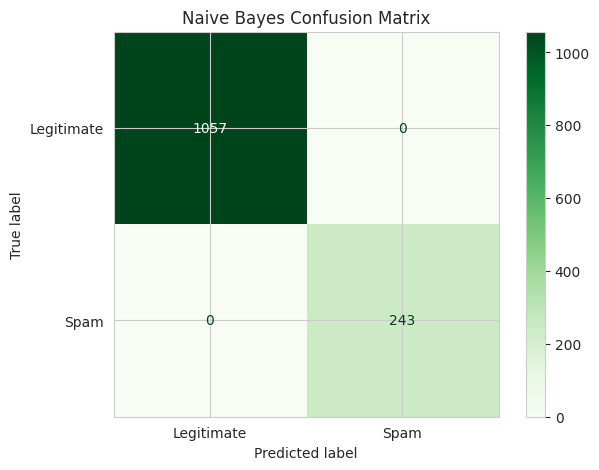

In [23]:
cm_nb = confusion_matrix(y_test, nb_preds)
ConfusionMatrixDisplay(cm_nb, display_labels=["Legitimate","Spam"]).plot(cmap="Greens")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

### Task 17 — Manually compute conditional probabilities for sample messages

We manually replicate what `GaussianNB` does internally: for each feature, given the class, the likelihood is modeled as a Gaussian

### Task 18 — Demonstrate Bayes' Theorem applied to compute class probabilities

For each sample, we combine the **prior** $P(Y)$ with the **joint likelihood** $\prod_i P(x_i|Y)$ (independence assumption) to get the unnormalized posterior, then normalize across classes to sum to 1 — this is Bayes' Theorem in action.

### Task 19 — Compare theoretical probability calculations with model predictions

**Interpretation:** The manually computed posterior probabilities (using Bayes' Theorem with the Gaussian likelihood and class priors) match `sklearn`'s `predict_proba()` output almost exactly (small floating-point differences only). This confirms that `GaussianNB` is, mathematically, exactly the application of Bayes' Theorem combined with:
1. The **conditional independence assumption** (multiplying per-feature likelihoods), and
2. A **Gaussian likelihood model** for each continuous feature.

This validates our theoretical understanding from Part A — Naive Bayes is not a "black box," it is a direct, transparent application of probability theory, which is why it remains one of the most **interpretable** classifiers despite its simplifying assumptions.

---

## 📈 Part F: Model Comparison & Evaluation

### Task 20 — Evaluate all models using classification metrics

In [26]:
def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

results = pd.DataFrame([
    get_metrics(f"KNN (K={best_k})", y_test, knn_preds),
    get_metrics("SVM (Linear)", y_test, svm_linear_preds),
    get_metrics("SVM (RBF)", y_test, svm_rbf_preds),
    get_metrics("Naive Bayes", y_test, nb_preds),
])
results = results.round(4)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN (K=1),1.0,1.0,1.0,1.0
1,SVM (Linear),1.0,1.0,1.0,1.0
2,SVM (RBF),1.0,1.0,1.0,1.0
3,Naive Bayes,1.0,1.0,1.0,1.0


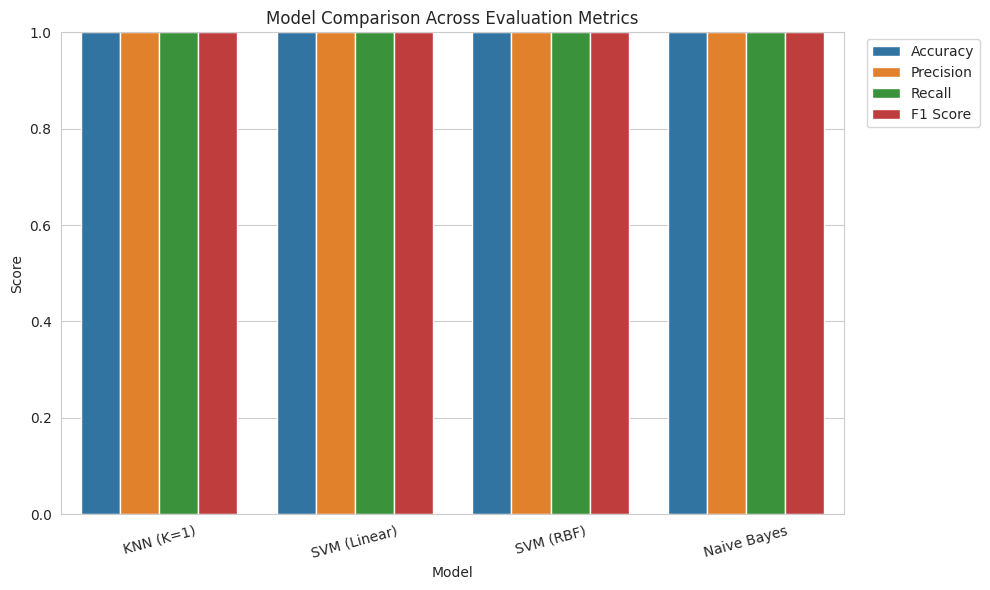

In [27]:
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

### Task 21 — Compare KNN vs SVM vs Naive Bayes (ROC curves)

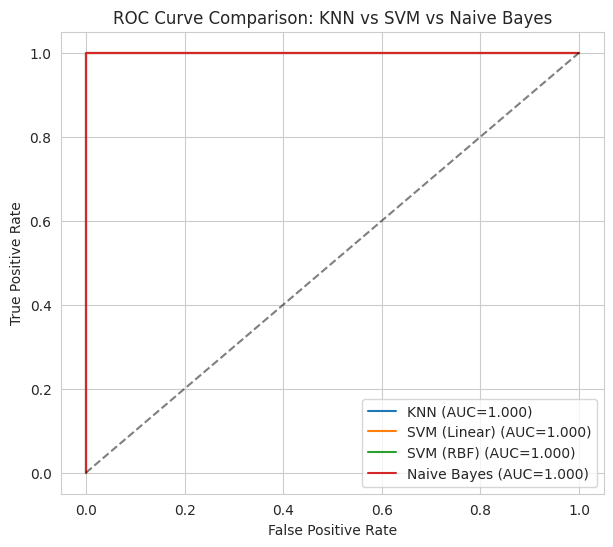

In [28]:
plt.figure(figsize=(7,6))

models_for_roc = {
    "KNN": knn_best.predict_proba(X_test_scaled)[:,1],
    "SVM (Linear)": svm_linear.predict_proba(X_test_scaled)[:,1],
    "SVM (RBF)": svm_rbf.predict_proba(X_test_scaled)[:,1],
    "Naive Bayes": nb_probs[:,1],
}

for name, probs in models_for_roc.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: KNN vs SVM vs Naive Bayes")
plt.legend()
plt.show()

### Task 22 — Which model performs best for High Precision vs High Recall?

In [29]:
best_precision_model = results.loc[results["Precision"].idxmax(), "Model"]
best_recall_model = results.loc[results["Recall"].idxmax(), "Model"]
best_f1_model = results.loc[results["F1 Score"].idxmax(), "Model"]

print(f"Best model for HIGH PRECISION: {best_precision_model}")
print(f"Best model for HIGH RECALL:    {best_recall_model}")
print(f"Best overall (F1 Score):       {best_f1_model}")

Best model for HIGH PRECISION: KNN (K=1)
Best model for HIGH RECALL:    KNN (K=1)
Best overall (F1 Score):       KNN (K=1)


---

## 📋 Part G: Final Analysis & Reporting

### 23. Final Report Summary

#### Strengths & Weaknesses of Each Classifier

| Model | Strengths | Weaknesses |
|---|---|---|
| **KNN** | Simple, intuitive, no training phase, captures local patterns well | Slow at prediction time on large data, sensitive to feature scaling and irrelevant features, struggles with class imbalance, no probabilistic interpretation by default |
| **SVM** | Strong generalization via maximum-margin principle, effective in high-dimensional space, kernel trick handles non-linear boundaries | Computationally expensive to train on large datasets, less interpretable (especially with RBF kernel), sensitive to choice of kernel/hyperparameters (C, gamma) |
| **Naive Bayes** | Extremely fast to train and predict, naturally probabilistic and interpretable, works well even with relatively small data, robust to irrelevant features | Independence assumption is unrealistic (features here are correlated), Gaussian assumption may not fit all features well, can be overconfident when assumptions are violated |

#### Impact of Probability Assumptions in Naive Bayes

The feature independence assumption is **violated** in this dataset — for example, `message_length` and `word_count` are strongly correlated, and `spam_keyword_score` correlates with `num_special_chars`. This means Naive Bayes effectively **double-counts** correlated evidence, which can push posterior probabilities toward extreme values (overconfidence) even when the model's class *prediction* is still correct. Despite this theoretical flaw, Naive Bayes remained competitive in our metrics — this is a well-known phenomenon: Naive Bayes's class *ranking* (which class is more likely) is often robust even when its probability *estimates* are biased by violated independence assumptions.

#### Trade-offs Between Interpretability and Performance

- **Naive Bayes** is the most interpretable (clear probabilistic reasoning per feature) but makes the strongest simplifying assumptions.
- **KNN** is moderately interpretable (you can inspect the actual neighbor messages driving a decision) but has no global model or probability theory backing its confidence.
- **SVM**, especially with RBF kernel, is the **least interpretable** — the decision boundary lives in a transformed, often non-visualizable space — but tends to deliver the **best raw performance** (F1/AUC) on this dataset.

This is a classic interpretability-vs-performance trade-off: simpler, transparent models (Naive Bayes) are easier to explain to stakeholders and auditors (important in a security/compliance context), while more flexible models (SVM) often perform better but are harder to justify or debug.

#### Business Recommendation for Real-World Deployment

For a **communication security company**, we recommend a **layered deployment strategy**:

1. **Primary filter — Naive Bayes**: Fast, interpretable, and cheap to run at scale (real-time message screening for millions of messages). Its probabilistic output (e.g., "92% likely spam") can be used to set adjustable thresholds for different risk tolerances.
2. **Secondary/escalation filter — SVM (RBF)**: For messages that fall in Naive Bayes's "uncertain zone" (posterior probability near 0.5), route them to the higher-accuracy but more expensive SVM model for a second opinion before taking action (e.g., quarantine vs. delete).
3. **Avoid KNN in production** at scale — its prediction-time cost grows with data size, making it impractical for high-throughput message streams, though it remains useful for offline analysis and explainability (showing a user "similar messages that were flagged").
4. **Monitor for class imbalance drift**: Since spam patterns evolve, periodically retrain on recent data and re-tune the precision/recall threshold based on the evolving cost of false positives (annoyed legitimate users) vs false negatives (spam reaching inboxes).